In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

tcga_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/TCGA/results/output_tables/MSA_TCGA/pruned_attribution_MSA_TCGA_SBS_abs_mutations.csv',
                  index_col=0)



In [2]:
# only looking at nonzero samples for linear regression
tcga_msa = tcga_msa[tcga_msa.loc[:,'SBS288D'] > 0]

In [3]:
# TCGA 

# now we need to look at the TCGA metadata to see if these samples have all the info we need 

# maybe we wanna do this per tumor location 
# I guess that would be in the clinical sheet

clinical = pd.read_table('/Users/kazachkova/Downloads/old_laptop_downloads/clinical.project-tcga-coad.2024-05-23/clinical.tsv',index_col=1)

clinical2 = pd.read_table('/Users/kazachkova/Downloads/old_laptop_downloads/clinical.project-tcga-read.2024-04-29/clinical.tsv',index_col=1)



all_clinical = pd.concat([clinical,clinical2])

# The right colon consists of the cecum, ascending colon, hepatic flexure and the right half of the transverse colon. The left colon consists of the left half of the transverse colon, splenic flexure, descending colon, and sigmoid

# C20 - Rectum	Rectum
# C18.7 - Sigmoid	Distal colon
# C18.3 - Hepatic flexure	Proximal colon
# C18.0 - Cecum	Proximal colon
# C18.2 - Right (ascending) colon	Proximal colon
# C18.6 - Left (descending) colon	Distal colon
# C19.9 - Rectosigmoid junction	Rectum
# C18.5 - Splenic flexure	Distal colon
# C18.4 - Transverse colon	Proximal colon
# C18.0 - Cecum; C18.2 - Right (ascending) colon	Proximal colon
# C18.6 - Left (descending) colon; C18.7 - Sigmoid	Distal colon
# C18.9 - Colon not otherwise specified	Other
# Other	Other
# C18.2 - Right (ascending) colon; C18.4 - Trans...	Proximal colon

for_map = pd.Series('Other',index = set(all_clinical.loc[:,'site_of_resection_or_biopsy']),dtype=str)
for_map.loc['Hepatic flexure of colon'] = 'Proximal'
for_map.loc['Transverse colon'] = 'Proximal'
for_map.loc['Cecum'] = 'Proximal'
for_map.loc['Splenic flexure of colon'] = 'Distal'
for_map.loc['Sigmoid colon'] = 'Distal'
for_map.loc['Rectum, NOS'] = 'Rectum'
for_map.loc['Ascending colon'] = 'Proximal'
for_map.loc['Rectosigmoid junction'] = 'Rectum'
for_map.loc['Descending colon'] = 'Distal'
for_map

all_clinical=all_clinical[~all_clinical.index.duplicated()]

# temp['subsite'] = for_map.loc[all_clinical.loc[temp.index,'site_of_resection_or_biopsy']].values


all_clinical['subsite'] = for_map.loc[all_clinical.loc[all_clinical.index,'site_of_resection_or_biopsy']].values


# tcga_keep= all_clinical.loc[tcga_keep][all_clinical.loc[good_tcga_muts,'age_at_index']!='\'--'].loc[:,'age_at_index'].index
# tcga_keep= all_clinical.loc[tcga_keep][all_clinical.loc[good_tcga_muts,'subsite']!='Other'].index



# and sex is fine here 
# tcga_keep= all_clinical.loc[good_tcga_muts][all_clinical.loc[good_tcga_muts,'treatment_or_therapy']!='yes'].index



In [4]:

all_clinical['SBS_D'] = tcga_msa.loc[:,'SBS288D']

from scipy import stats 
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm

import statsmodels.formula.api as smf

purity = pd.Series(index = tcga_msa.index)
# now do it for all our samples of interest
import os

for sample in tcga_msa.index:
    
    if not os.path.exists('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/battenberg_TCGA_data/results/' + sample + '/' + sample + '_tumor_rho_and_psi.txt'):
                          continue
  
    
    rho_psi = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/battenberg_TCGA_data/results/' + sample + '/' + sample + '_tumor_rho_and_psi.txt')

    purity.loc[sample] = rho_psi[rho_psi.loc[:,'is.best'] == True].loc[:,'rho'].values[0]
    
    


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86512/961475587.py:10: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  purity = pd.Series(index = tcga_msa.index)


In [5]:
all_clinical['purity'] = purity

all_clinical.loc[:,'age_at_index'] = all_clinical.loc[:,'age_at_index'].str.replace('\'--','NAN').astype(float)

all_clinical.loc[:,'gender'] = all_clinical.loc[:,'gender'].str.replace('\'--','NAN').astype(str)

# keep only our samples
all_clinical = all_clinical[all_clinical.loc[:,'SBS_D']== all_clinical.loc[:,'SBS_D']]

all_clinical['age_diag']  = all_clinical.loc[:,'age_at_index']
all_clinical['sex']  = all_clinical.loc[:,'gender']
all_clinical['tumor_subsite']  = all_clinical.loc[:,'subsite']


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86512/2326741897.py:3: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  all_clinical.loc[:,'age_at_index'] = all_clinical.loc[:,'age_at_index'].str.replace('\'--','NAN').astype(float)


In [6]:
all_clinical.loc[:,'tumor_subsite'].unique()
all_clinical['tumor_subsite'] = all_clinical['tumor_subsite'].str.replace('Proximal', 'Proximal colon').str.replace('Distal','Distal colon')

all_clinical['stage_simple'] = all_clinical.loc[:,'ajcc_pathologic_stage'].str.split(' ').str[-1]
all_clinical.loc[:,'stage_simple'] = all_clinical.loc[:,'stage_simple'].str.replace('A','').str.replace('B','').str.replace('C','')


all_clinical.loc[:,'stage_simple'] = all_clinical.loc[:,'stage_simple'].str.replace('\'--','NAN')

all_clinical['simple_stage_numeric'] = all_clinical['stage_simple'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').astype(float)


all_clinical['Stage'] = all_clinical['stage_simple'].str.replace('IV','4').str.replace('III','3').str.replace('II','2').str.replace('I','1').astype(float)


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_86512/3969617610.py:79: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(reset_labels)


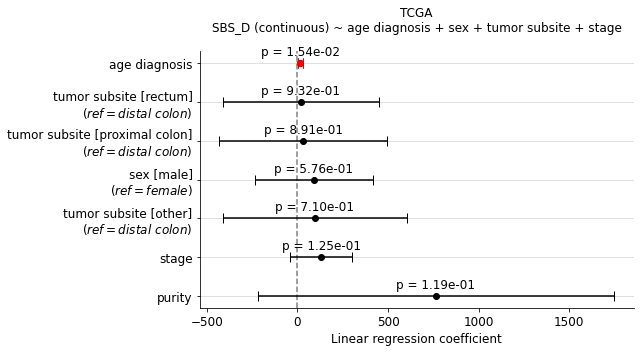

In [8]:
model = smf.glm(formula = 'SBS_D' + " ~ age_diag + sex + tumor_subsite + purity + Stage", 
            data =all_clinical)
            #family = sm.families.Binomial())

result = model.fit()
result_table = result.summary2().tables[1]


from statsmodels.stats.multitest import multipletests



result_table=result_table.drop('Intercept')
result_table = result_table.reset_index()


result_table = result_table.sort_values('Coef.',ascending=False)


fig,ax = plt.subplots(figsize=(9,5))
plt.errorbar(result_table.loc[:,'Coef.'], result_table.loc[:,'index'],
             xerr=result_table.loc[:,'Std.Err.']*2, fmt="o",capsize=5,color='black')



result_table_ = result_table[result_table.loc[:,'P>|z|'] < .05]
# only report the dietary variables
# result_table_ = result_table[result_table.loc[:,'index'].isin(corrected[corrected<.05].index)]
plt.errorbar(result_table_.loc[:,'Coef.'], result_table_.loc[:,'index'],
             xerr=result_table_.loc[:,'Std.Err.']*2, fmt="o",color='red',capsize=5)

plt.xlabel('coef')
plt.axvline(0,color='black',alpha=.5,linestyle='--')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


result_table.index = result_table.loc[:,'index']
for i, txt in enumerate(result_table.loc[:,'P>|z|']):
    addition = ''
    y_numeric = ax.yaxis.convert_units(result_table.loc[:,'index'][i])
    offset = 0.2 
#     if 'freq' in result_table.index[i] and corrected.loc[result_table.index[i]] < 0.05:
#         addition = ' (q-value = ' + str(round(corrected.loc[result_table.index[i]],3)) + ')'
    ax.annotate('p = ' + '{:0.2e}'.format(txt) + addition,(result_table.loc[:,'Coef.'][i],
                      y_numeric + .2),fontsize=12,ha='center',
                
              )
# for i, txt in enumerate(result_table.loc[:,'P>|z|']):
#     ax.annotate('{:0.2e}'.format(txt),(result_table.loc[:,'0.975]'][i]+50,
#                       result_table.loc[:,'index'][i]),fontsize=14)

 
plt.xlabel('Linear regression coefficient')

reset_labels = []
for label in ax.get_yticklabels():
    text = label.get_text()
#     if variable in text:
#         label = label.set_color('blue')
    text = text.replace('[T.',' [').replace('_',' ').replace(' diag',' diagnosis').replace('Stage','stage').lower()
    if 'subsite' in text:
        text = text.replace(']',']\n$\mathit{(ref=distal\ colon)}$')
    
    if 'grade' in text:
        text = text.replace(']',']\n$\mathit{(ref=high)}$').lower().replace('low grade','low')
        
    if 'sex' in text:
        text = text.replace(']',']\n$\mathit{(ref=female)}$')
    reset_labels.append(text)    
    


ax.set_yticklabels(reset_labels)    
plt.grid(axis='y',alpha=.5)
# plt.grid(axis='y')

plt.title('TCGA\nSBS_D (continuous) ~ age diagnosis + sex + tumor subsite + stage',
         pad=20)
plt.tight_layout()

# plt.savefig('plots_for_responses/TCGA_clinipatho_continuous.png',dpi=300)
